<a href="https://colab.research.google.com/github/Alenushka2013/ML_for_people_tasks/blob/main/HW_4_1_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# завантаження даних
train_fname = '/content/tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [3]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [5]:
# кількість пропущених значень
raw_df.isna().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [6]:
# рядки з пропущеними значеннями
raw_df[raw_df.isna().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


In [7]:
# видалення рядків з пропущеними значеннями
raw_df = raw_df.dropna()

In [8]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [9]:
# розподіл класів у відсотках
raw_df.sentiment.value_counts(normalize=True) * 100

,proportion
sentiment,
neutral,40.454876
positive,31.229985
negative,28.315138


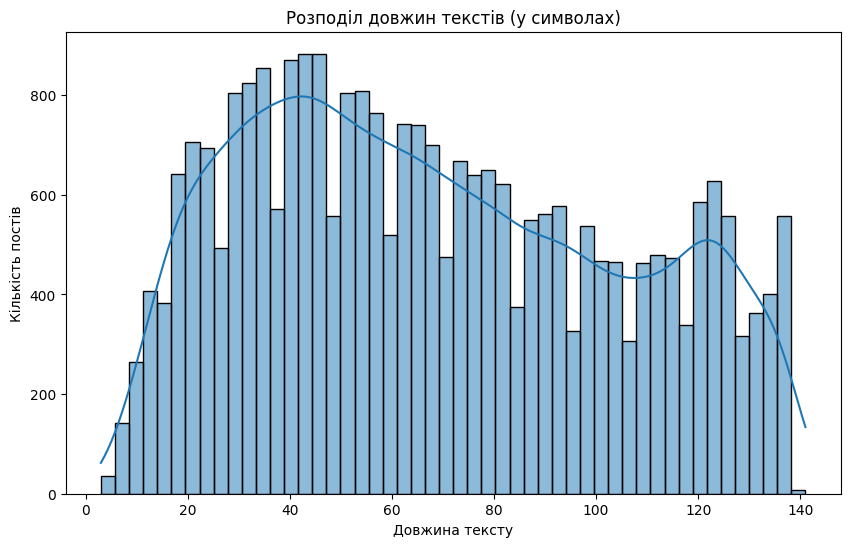

In [10]:
# визначення довжин текстів
raw_df['text_length'] = raw_df['text'].astype(str).apply(len)

# візуалізація
plt.figure(figsize=(10,6))
sns.histplot(raw_df['text_length'], bins=50, kde=True)
plt.title('Розподіл довжин текстів (у символах)')
plt.xlabel('Довжина тексту')
plt.ylabel('Кількість постів')
plt.show()

In [11]:
raw_df['text_length'].describe()

,text_length
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


**Спостереження:**

*Розподіл класів*

У наборі даних представлено три класи сентименту: neutral, positive та negative.
Їхній розподіл є наступним:

Neutral — 40.45 % усіх прикладів;

Positive — 31.23 %;

Negative — 28.32 %.

Таким чином, нейтральні пости є найпоширенішими, становлячи близько двох п’ятих від загальної кількості.
Позитивні й негативні тексти трапляються дещо рідше, причому частка позитивних постів трохи перевищує негативні.

У цілому, розподіл класів є відносно збалансованим, хоча спостерігається невелика перевага нейтрального класу.

*Довжина текстів*

 - найбільше постів мають довжину близько 30–50 символів — саме в цьому діапазоні спостерігається пік частоти;

 - далі частота поступово зменшується, хоча є певні коливання, тобто зустрічаються і короткі, і довгі пости;

 - розподіл є асиметричним, із невеликим зміщенням у бік коротших текстів — короткі пости трапляються частіше, ніж дуже довгі;

 - дуже довгі тексти (понад 120 символів) трапляються рідко.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [12]:
import re
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize

# Завантаження ресурсів NLTK
nltk.download('stopwords')

LANG = 'english'
stemmer = SnowballStemmer(LANG)
stop_words = set(stopwords.words(LANG))

# 1. Функція очищення і препроцесингу
def preprocess_text(text):
    # нижній регістр
    text = text.lower()
    # видалення небуквених символів
    text = re.sub(r'[^a-zа-яіїєґ0-9\s]', ' ', text)
    # токенізація
    tokens = text.split()
    # видалення стоп-слів
    tokens = [word for word in tokens if word not in stop_words]
    # стеммінг
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

# 2. Застосування до колонки raw_df['text']
raw_df['clean_text'] = raw_df['text'].apply(preprocess_text)

# 3. Аналіз унікальних слів для вибору розміру словника
all_words = ' '.join(raw_df['clean_text']).split()
vocab_size = len(set(all_words))
print(f"Унікальних слів після обробки: {vocab_size}")

# 4. Векторизація з обмеженням розміру словника
# наприклад, 5000 найчастотніших слів
vectorizer = CountVectorizer(max_features=5000)

X_bow = vectorizer.fit_transform(raw_df['clean_text'])
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

print(bow_df.shape)
bow_df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Унікальних слів після обробки: 20842
(27480, 5000)


,00,000,01,03,04,05,06,07,08,09,...,zack,ze,zealand,zelda,zero,zoe,zombi,zone,zoo,zulu
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
from collections import Counter

word_counts = Counter(all_words)
print(*word_counts.most_common(10), sep = '\n')  # найчастотніші слова

('day', 2451)
('go', 2384)
('get', 1916)
('good', 1600)
('work', 1530)
('love', 1486)
('like', 1462)
('http', 1247)
('today', 1155)
('time', 1104)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [14]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(bow_df, raw_df.sentiment,
                                                                        test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000, solver='sag')

In [15]:
%%time
model.fit(X_train_bow, y_train)

CPU times: user 3min 47s, sys: 347 ms, total: 3min 47s
Wall time: 3min 57s


LogisticRegression(max_iter=1000, solver='sag')

In [16]:
train_preds = model.predict(X_test_bow)

In [17]:
pd.Series(train_preds).value_counts()

,count
neutral,3768
positive,2451
negative,2025


LogisticRegression Results:
              precision    recall  f1-score   support

    negative       0.70      0.60      0.65      2356
     neutral       0.63      0.71      0.67      3343
    positive       0.75      0.72      0.73      2545

    accuracy                           0.68      8244
   macro avg       0.69      0.68      0.68      8244
weighted avg       0.69      0.68      0.68      8244

Accuracy: 0.6811014070839398


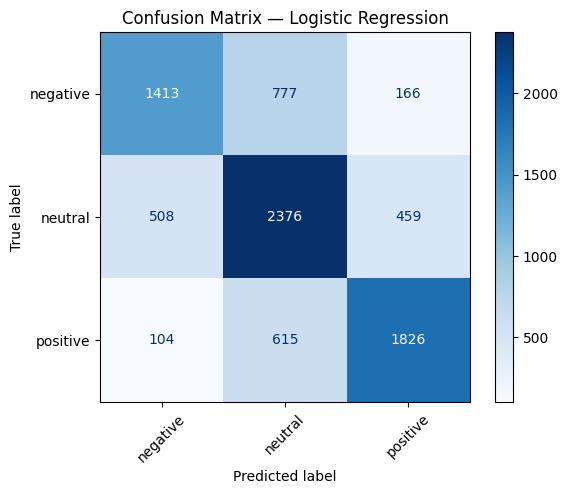

In [18]:
# Оцінка
print("LogisticRegression Results:")
print(classification_report(y_test, train_preds))
print("Accuracy:", accuracy_score(y_test, train_preds))

cm = confusion_matrix(y_test, train_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

Decision Tree Results:
              precision    recall  f1-score   support

    negative       0.78      0.30      0.44      2356
     neutral       0.53      0.87      0.66      3343
    positive       0.78      0.57      0.66      2545

    accuracy                           0.62      8244
   macro avg       0.70      0.58      0.59      8244
weighted avg       0.68      0.62      0.60      8244

Accuracy: 0.6169335274138767


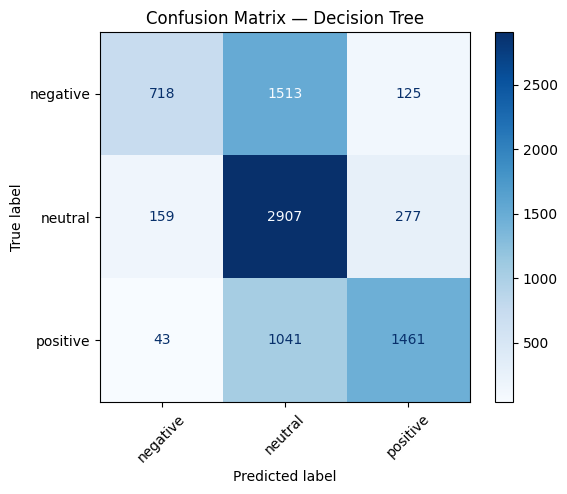

In [19]:
# Створення моделі дерева
tree_model = DecisionTreeClassifier(
    max_depth=20,      # обмеження глибини (запобігає перенавчанню)
    min_samples_split=5,
    random_state=42
)

# Навчання
tree_model.fit(X_train_bow, y_train)

# Прогнозування
tree_preds = tree_model.predict(X_test_bow)

# Оцінка
print("Decision Tree Results:")
print(classification_report(y_test, tree_preds))
print("Accuracy:", accuracy_score(y_test, tree_preds))

cm = confusion_matrix(y_test, tree_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — Decision Tree")
plt.show()

XGBoost Results:
              precision    recall  f1-score   support

    negative       0.77      0.50      0.61      2356
     neutral       0.62      0.80      0.70      3343
    positive       0.76      0.73      0.75      2545

    accuracy                           0.69      8244
   macro avg       0.72      0.68      0.68      8244
weighted avg       0.71      0.69      0.69      8244

Accuracy: 0.6922610383309074


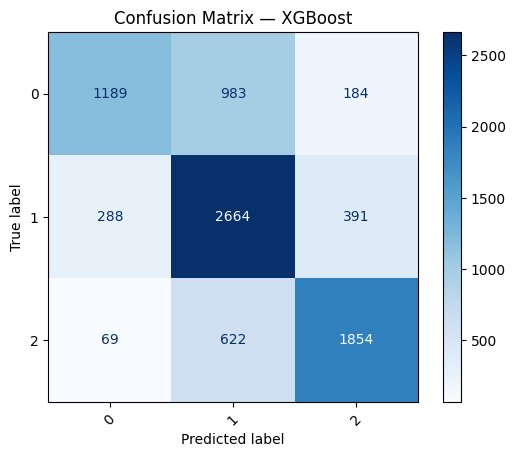

In [20]:
# Кодування міток у числа
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Модель XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    #use_label_encoder=False,
    eval_metric='mlogloss'
)

# Навчання
xgb_model.fit(X_train_bow, y_train_enc)

# Прогнозування
xgb_preds_enc = xgb_model.predict(X_test_bow)

# Декодування назад у текстові мітки
xgb_preds = le.inverse_transform(xgb_preds_enc)

# Оцінка
print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print("Accuracy:", accuracy_score(y_test, xgb_preds))

cm = confusion_matrix(y_test, xgb_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — XGBoost")
plt.show()


In [21]:
results = {
    "Logistic Regression": accuracy_score(y_test, train_preds),
    "Decision Tree": accuracy_score(y_test, tree_preds),
    "XGBoost": accuracy_score(y_test, xgb_preds)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.681101
1        Decision Tree  0.616934
2              XGBoost  0.692261


**Спостереження:**

Logistic Regression	швидка, інтерпретована, добре працює з текстом, не вловлює складні взаємодії

Decision Tree	інтерпретована, враховує нелінійності	схильна до перенавчання

XGBoost	висока точність, добре працює з різними ознаками	повільніше працює, складніше тюнити


Найкраще, з урахуванням швидкості, спрацювала модель логістичної регресії.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [22]:
# Отримуємо імена ознак (слів)
feature_names = np.array(vectorizer.get_feature_names_out())

# Отримаємо ваги (коефіцієнти) з моделі
coefs = model.coef_

# Отримуємо 3 рядки (по одному для кожного sentiment)
classes = model.classes_

# Для кожного класу виведемо топ-10 найважливіших слів
top_n = 10
for i, sentiment in enumerate(classes):
    # Сортуємо за коефіцієнтами
    top_positive_idx = np.argsort(coefs[i])[-top_n:][::-1]
    top_negative_idx = np.argsort(coefs[i])[:top_n]

    print(f"\n Sentiment: {sentiment}")
    print(f"Top +{top_n} influential words:")
    print(feature_names[top_positive_idx])
    print(f"Bottom -{top_n} (least / opposite influence):")
    print(feature_names[top_negative_idx])


 Sentiment: negative
Top +10 influential words:
['sad' 'suck' 'bore' 'sorri' 'hate' 'miss' 'disappoint' 'fail' 'shame'
 'worst']
Bottom -10 (least / opposite influence):
['awesom' 'glad' 'love' 'cute' 'congrat' 'thank' 'smile' 'enjoy' 'welcom'
 'bless']

 Sentiment: neutral
Top +10 influential words:
['chan' 'parvo' 'jst' 'starwarsday' 'fals' 'gent' 'cop' 'idol' 'logic'
 'semest']
Bottom -10 (least / opposite influence):
['delici' 'troubl' 'congratul' 'deserv' 'sweeti' 'nut' 'worri' 'proud'
 'known' 'thrill']

 Sentiment: positive
Top +10 influential words:
['awesom' 'cute' 'thank' 'love' 'amaz' 'congrat' 'enjoy' 'great' 'nice'
 'congratul']
Bottom -10 (least / opposite influence):
['shame' 'sad' 'sorri' 'suck' 'unfortun' 'hate' 'bore' 'poor' 'jealous'
 'miss']


**Спостереження:**

з отриманих топових слів для кожного сентименту можна зробити такі висновки про логіку моделі та якість її "розуміння" емоцій:

Sentiment: *Negative*

Top +10 influential words:

sad, suck, bore, sorri, hate, miss, fail, disappoint, shame, stupid

**Висновок:**
Це класичні слова, які несуть негативний емоційний відтінок.
Вони пов’язані з розчаруванням, жалем, невдачею або неприязню — типовими ознаками негативного сентименту.
Модель добре навчилася розпізнавати негатив.


Bottom -10:

слова типу “love”, “thank”, “cute” — це природні антоніми позитивного настрою, тому логічно, що вони зменшують ймовірність негативної класифікації.

Sentiment: *Neutral*

Top +10 influential words:

nigga, parvo, gent, hummmmm, cop, starwarsday, chan, jst, semest, fals

**Висновок:**

Тут видно, що нейтральна категорія включає:

сленгові або рідковживані слова без яскравої емоційності (jst, chan);

теми або факти без оцінки — наприклад, “cop” (поліцейський), “semest” (семестр);

навіть “starwarsday” — це просто тематичне слово, не емоційне.

Отже, модель вірно “виловлює” нейтральність через відсутність емоційних слів.

Bottom -10:

Тут бачимо слова “troubl”, “delici”, “sweeti”, “proud” тощо — вони мають емоційний відтінок, тому логічно, що вони знижують нейтральність.

Sentiment: *Positive*

Top +10 influential words:

awesom, thank, cute, love, amaz, great, nice, congrat, enjoy, gorgeous

**Висновок:**

Це абсолютно логічні позитивні маркери емоцій — подяка, любов, задоволення, захоплення.

Модель дуже добре “розуміє” позитив.

Bottom -10:

Слова типу “sad”, “suck”, “bore”, “hate” — тобто типові негативні індикатори, що природно зменшують ймовірність позитивної класифікації.

***Загальний висновок:***

Логістична регресія чітко відділяє емоційно забарвлені слова (love, hate, sad, great) від нейтральних.

Ваги цілком інтерпретовані — тобто можна пояснити, чому саме модель приймає певне рішення.

Негатив та позитив мають очікувані патерни, що свідчить про якісне навчання.

Нейтральний клас виявився складнішим: він часто містить "беземоційні", сленгові або тематичні слова.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 4. Використовуємо той самий препроцесинг
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,  # важливо: застосовуємо ту саму функцію
    max_features=5000              # обмежимо словник як у BoW (для чесного порівняння)
)

X_tfidf = tfidf_vectorizer.fit_transform(raw_df['text'])
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(tfidf_df.shape)

(27480, 5000)


LogisticRegression Results:
              precision    recall  f1-score   support

    negative       0.72      0.57      0.63      2356
     neutral       0.62      0.75      0.68      3343
    positive       0.76      0.70      0.73      2545

    accuracy                           0.68      8244
   macro avg       0.70      0.67      0.68      8244
weighted avg       0.69      0.68      0.68      8244

Accuracy: 0.6829209121785541


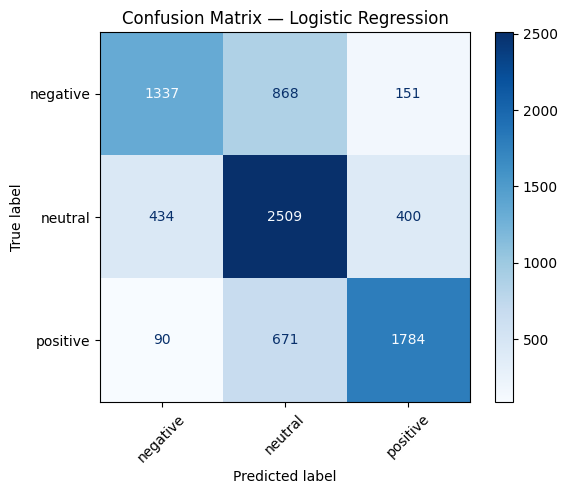

In [24]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(tfidf_df, raw_df.sentiment,
                                                                        test_size=0.3, random_state=42)
# LogisticRegression
model = LogisticRegression(max_iter=1000, solver='sag')
model.fit(X_train_tfidf, y_train)
train_preds = model.predict(X_test_tfidf)

# Оцінка
print("LogisticRegression Results:")
print(classification_report(y_test, train_preds))
print("Accuracy:", accuracy_score(y_test, train_preds))

cm = confusion_matrix(y_test, train_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

Decision Tree Results:
              precision    recall  f1-score   support

    negative       0.78      0.30      0.43      2356
     neutral       0.53      0.87      0.66      3343
    positive       0.78      0.56      0.65      2545

    accuracy                           0.61      8244
   macro avg       0.70      0.58      0.58      8244
weighted avg       0.68      0.61      0.59      8244

Accuracy: 0.6126880155264435


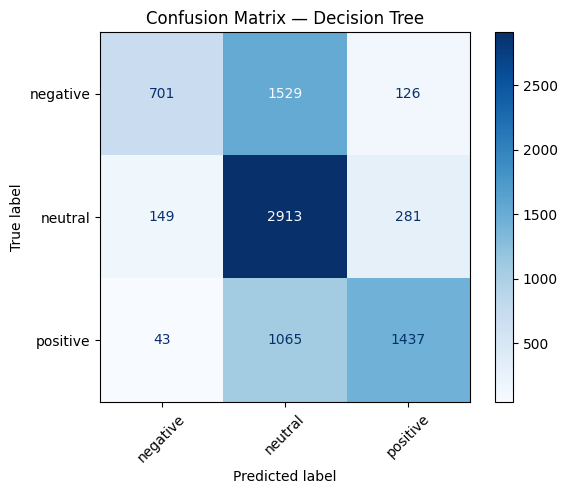

In [25]:
# DecisionTree
tree_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

# Навчання
tree_model.fit(X_train_tfidf, y_train)

# Прогнозування
tree_preds = tree_model.predict(X_test_tfidf)

# Оцінка
print("Decision Tree Results:")
print(classification_report(y_test, tree_preds))
print("Accuracy:", accuracy_score(y_test, tree_preds))

cm = confusion_matrix(y_test, tree_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — Decision Tree")
plt.show()

XGBoost Results:
              precision    recall  f1-score   support

    negative       0.77      0.49      0.60      2356
     neutral       0.61      0.81      0.70      3343
    positive       0.77      0.71      0.74      2545

    accuracy                           0.69      8244
   macro avg       0.72      0.67      0.68      8244
weighted avg       0.71      0.69      0.68      8244

Accuracy: 0.6881368267831149


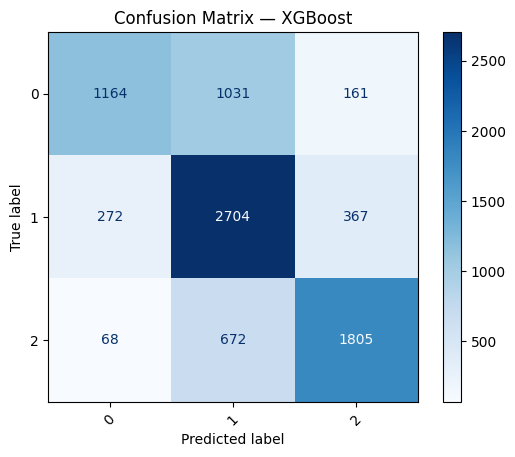

In [26]:
# Кодування міток у числа
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Модель XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    #use_label_encoder=False,
    eval_metric='mlogloss'
)

# Навчання
xgb_model.fit(X_train_tfidf, y_train_enc)

# Прогнозування
xgb_preds_enc = xgb_model.predict(X_test_tfidf)

# Декодування назад у текстові мітки
xgb_preds = le.inverse_transform(xgb_preds_enc)

# Оцінка
print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print("Accuracy:", accuracy_score(y_test, xgb_preds))

cm = confusion_matrix(y_test, xgb_preds)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — XGBoost")
plt.show()

In [27]:
results = {
    "Logistic Regression": accuracy_score(y_test, train_preds),
    "Decision Tree": accuracy_score(y_test, tree_preds),
    "XGBoost": accuracy_score(y_test, xgb_preds)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.682921
1        Decision Tree  0.612688
2              XGBoost  0.688137


In [28]:
# Отримуємо імена ознак (слів)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Отримаємо ваги (коефіцієнти) з моделі
coefs = model.coef_

# Отримуємо 3 рядки (по одному для кожного sentiment)
classes = model.classes_

# Для кожного класу виведемо топ-10 найважливіших слів
top_n = 10
for i, sentiment in enumerate(classes):
    # Сортуємо за коефіцієнтами
    top_positive_idx = np.argsort(coefs[i])[-top_n:][::-1]
    top_negative_idx = np.argsort(coefs[i])[:top_n]

    print(f"\n Sentiment: {sentiment}")
    print(f"Top +{top_n} influential words:")
    print(feature_names[top_positive_idx])
    print(f"Bottom -{top_n} (least / opposite influence):")
    print(feature_names[top_negative_idx])


 Sentiment: negative
Top +10 influential words:
['sad' 'miss' 'sorri' 'suck' 'hate' 'bore' 'fail' 'stupid' 'sick' 'poor']
Bottom -10 (least / opposite influence):
['love' 'thank' 'awesom' 'hope' 'great' 'nice' 'glad' 'cute' 'enjoy'
 'better']

 Sentiment: neutral
Top +10 influential words:
['cop' 'thru' 'jst' 'starwarsday' 'question' 'except' 'fals' 'notic'
 'logic' 'sent']
Bottom -10 (least / opposite influence):
['happi' 'good' 'worri' 'thank' 'great' 'excit' 'headach' 'fun' 'nice'
 'fail']

 Sentiment: positive
Top +10 influential words:
['love' 'thank' 'awesom' 'great' 'nice' 'happi' 'good' 'hope' 'enjoy'
 'amaz']
Bottom -10 (least / opposite influence):
['miss' 'sad' 'sorri' 'suck' 'tire' 'hate' 'bore' 'poor' 'bad' 'shame']


**Спостереження:**

Модель Логістичної регресії більш рівномірно визначає класи повідомлень при рівних значеннях метрики accuracy, порівняно з  XGBoost. Модель дерева рішень працює значно слабіше.

Sentiment: *negative*

Найвпливовіші слова:
['sad', 'miss', 'sorri', 'suck', 'hate', 'bore', 'fail', 'stupid', 'sick', 'poor']

Це типові маркери негативу — емоційно забарвлені слова зі стабільним негативним відтінком.

Протилежні (мінімальний вплив або протилежна полярність):
['love', 'thank', 'awesom', 'hope', 'great', 'nice', 'glad', 'cute', 'enjoy', 'better']

Sentiment: *neutral*

Найвпливовіші:
['cop', 'thru', 'jst', 'starwarsday', 'question', 'except', 'fals', 'notic', 'logic', 'sent']

Багато "нейтральних" слів, які не несуть емоційного змісту, що відповідає очікуванню.

Протилежні (схильні до позитиву):
['happi', 'good', 'worri', 'thank', 'great', 'excit', 'headach', 'fun', 'nice', 'fail']

Sentiment: *positive*

Найвпливовіші:
['love', 'thank', 'awesom', 'great', 'nice', 'happi', 'good', 'hope', 'enjoy', 'amaz']

Чітко позитивні емоційні слова.

Протилежні (негативні):
['miss', 'sad', 'sorri', 'suck', 'tire', 'hate', 'bore', 'poor', 'bad', 'shame']


**Висновок**

Різниця в точності мінімальна, але якість представлення тексту у TF-IDF помітно вища, позитивні й негативні маркери виглядають більш "чистими" — без випадкових домішок.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [33]:
# Розділення з поверненням індексів
X_train_text, X_test_text, y_train, y_test = train_test_split(
    raw_df['text'], raw_df['sentiment'],
    test_size=0.3, random_state=42, stratify=raw_df['sentiment']
)

# Векторизація TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Навчання моделі
model = LogisticRegression(max_iter=1000, solver='sag')
model.fit(X_train_tfidf, y_train)
train_preds = model.predict(X_test_tfidf)

# Маска помилок
mistakes = y_test != train_preds

# Створюємо DataFrame лише з помилкових прогнозів
errors = pd.DataFrame({
    "text": X_test_text[mistakes],
    "true_label": y_test[mistakes],
    "pred_label": train_preds[mistakes]
})

print(f"Кількість помилкових прогнозів: {len(errors)}")
errors.head(10)

Кількість помилкових прогнозів: 2604


,text,true_label,pred_label
2664,wearing a pair of trousers that were loose las...,negative,neutral
16359,I saw the game not a huge cavs fan lol. they ...,neutral,positive
7479,"Oh ok,Thanks.Dont know where the courthouse i...",negative,positive
27330,"unfortunetly no I wish, I mean sometimes lik...",negative,positive
3291,Tracky Daks are one of the only good things a...,positive,neutral
19463,hopefully it don`t go that far sometimes I f...,positive,neutral
26543,"Time to get ready for wrk! Ahhhh, I dnt wanna ...",negative,neutral
7190,not so good,negative,positive
16377,bout tuh head out an find sum wher tuh go an c...,positive,neutral
9239,_precious06 sooo mad,neutral,negative


Аналіз помилок класифікатора (TF-IDF)
| №     | Текст                                                            | Справжня мітка | Прогноз моделі | Коментар                                                                                                                               |
| :---- | :--------------------------------------------------------------- | :------------- | :------------- | :------------------------------------------------------------------------------------------------------------------------------------- |
| 2664  | *“wearing a pair of trousers that were loose last week”*         | negative       | neutral        | Слабко виражена емоція; слово *“loose”* може не нести явного негативу — модель не вловила контекст «раніше були великі, тепер — схуд». |
| 16359 | *“I saw the game not a huge cavs fan lol. they played well”*     | neutral        | positive       | Сарказм / змішаний тон (“not a fan” vs “played well”) — TF-IDF не розпізнає іронії.                                                    |
| 7479  | *“Oh ok, thanks. Dont know where the courthouse is.”*            | negative       | positive       | Ввічлива форма (“thanks”) переважила, хоча загалом зміст нейтрально-негативний.                                                        |
| 27330 | *“unfortunetly no I wish, I mean sometimes like…”*               | negative       | positive       | Орфографічна помилка (*unfortunetly*) і неявне розчарування — модель не розпізнає відтінків.                                           |
| 3291  | *“Tracky Daks are one of the only good things about winter”*     | positive       | neutral        | Слово *“good”* не мало достатньої ваги; короткий текст з малою кількістю маркерів позитиву.                                            |
| 19463 | *“hopefully it don’t go that far sometimes I feel like it will”* | positive       | neutral        | Суперечливі емоції — позитивне слово *“hopefully”*, але зміст із побоюванням.                                                          |
| 26543 | *“Time to get ready for wrk! Ahhhh, I dnt wanna go.”*            | negative       | neutral        | Неявний негатив через розмовну мову, емоційні вигуки — TF-IDF їх не враховує.                                                          |
| 7190  | *“not so good”*                                                  | negative       | positive       | Простий вираз, який інверсно змінює сенс; “not” не розпізнається контекстно (бо TF-IDF не розуміє зв’язку між словами).                |
| 16377 | *“bout tuh head out an find sum wher tuh go an chill”*           | positive       | neutral        | Сленг, орфографічні відхилення; токенайзер не розпізнає неформальні слова.                                                             |
| 9239  | *“_precious06 sooo mad”*                                         | neutral        | negative       | Модель реагує на *“mad”*, хоча в соцмережному контексті це може бути “excited”, а не “angry”.                                          |


**Висновок:**

Помилки через контекст і заперечення — вирази типу “not good” або “not bad” некоректно класифікуються, бо TF-IDF не враховує порядок слів.

Сленг, орфографічні помилки, скорочення — слова на кшталт “tuh”, “wrk”, “unfortunetly” не розпізнаються правильно.

Сарказм та мікс емоцій — фрази з подвійним змістом (“not a fan lol”, “hopefully it won’t”) моделі складно зрозуміти без семантики.

Як можна поліпшити якість класифікації:

 - покращити текстову обробку: додати обробку скорочень, розширити запас стоп-слів, щоб виключити малозмістовні “lol”, “ahhhh” іт.д.
 - використати векторизатори, які врахоують контекст і порядок слів
 - оптимізувати модель, виконати тюнинг гіперпараметрів, балансувати класи.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model